# Model Training

This notebook trains and runs inference with the two YOLO segmentation models, one per stage. Stage 1 finds melanoma versus everything else, stage 2 segments the remaining diagnosis classes.

Training already ran for both stages, so the train calls here are kept commented out for reference. What we actually run is loading the saved checkpoints and generating predictions on the test set, with and without background removal.


In [1]:
import sys
import warnings
warnings.filterwarnings('ignore')
# add the project root to the path so the src package can be imported
sys.path.append('..')

import yaml
from ultralytics import YOLO
from src.inference_utils.model_predict import predict

## Load configs

We'll pull in the stage 1 config, plus the YOLO data yaml it references. The next few cells just print each one out for a quick look.

In [2]:
s1_data_yaml_path = '../data/processed/Stage-1/data.yaml'
s1_model_args_path = '../data/processed/Stage-1/model_args.yaml'

s2_data_yaml_path = '../data/processed/Stage-2/data.yaml'
s2_model_args_path = '../data/processed/Stage-2/model_args.yaml'

s1_weights = {'best': '../outputs/checkpoints/stage-1/best.pt',
              'last': '../outputs/checkpoints/stage-1/last.pt'}
s2_weights = {'best': '../outputs/checkpoints/stage-2/best.pt',
              'last': '../outputs/checkpoints/stage-2/last.pt'}

s1_save_dir = '../outputs/predictions/stage-1/'
s2_save_dir = '../outputs/predictions/stage-2/'

with open(s1_data_yaml_path,'r') as f:

    s1_data_yaml = yaml.safe_load(f)

with open(s1_model_args_path,'r') as f:

    s1_model_args = yaml.safe_load(f)


with open(s2_data_yaml_path,'r') as f:

    s2_data_yaml = yaml.safe_load(f)

with open(s2_model_args_path,'r') as f:

    s2_model_args = yaml.safe_load(f)


Let's look at each config to confirm it loaded correctly, starting with the stage 1 data yaml.

In [3]:
s1_data_yaml

{'train': 'C:/Users/ibrah.HIMA/OneDrive/Desktop/Full AI/Projects/GitHub - Kaggle Projects/skin-lesion-segmentation/data/processed/Stage-1/train/images',
 'val': 'C:/Users/ibrah.HIMA/OneDrive/Desktop/Full AI/Projects/GitHub - Kaggle Projects/skin-lesion-segmentation/data/processed/Stage-1/val/images',
 'test': 'C:/Users/ibrah.HIMA/OneDrive/Desktop/Full AI/Projects/GitHub - Kaggle Projects/skin-lesion-segmentation/data/processed/Stage-1/test/images',
 'nc': 2,
 'names': ['Not Mel', 'Mel']}

Now stage 2's data yaml.

In [4]:
s2_data_yaml

{'train': 'C:/Users/ibrah.HIMA/OneDrive/Desktop/Full AI/Projects/GitHub - Kaggle Projects/skin-lesion-segmentation/data/processed/Stage-2/train/images',
 'val': 'C:/Users/ibrah.HIMA/OneDrive/Desktop/Full AI/Projects/GitHub - Kaggle Projects/skin-lesion-segmentation/data/processed/Stage-2/val/images',
 'test': 'C:/Users/ibrah.HIMA/OneDrive/Desktop/Full AI/Projects/GitHub - Kaggle Projects/skin-lesion-segmentation/data/processed/Stage-2/test/images',
 'nc': 6,
 'names': ['AKIEC', 'BCC', 'BKL', 'DF', 'NV', 'VASC']}

And the training arguments for each stage.

In [5]:
s1_model_args

{'epochs': 35,
 'save': True,
 'imgsz': 516,
 'batch': 128,
 'patience': 7,
 'optimizer': 'AdamW',
 'lr0': 0.0005,
 'lrf': 0.01,
 'plots': True,
 'verbose': True,
 'device': 'cuda',
 'workers': 4,
 'project': 'logs',
 'name': 'stage-1',
 'save_dir': '../outputs/logs/stage-1',
 'auto_augment': 'None',
 'augment': True,
 'mosaic': 0.0,
 'mixup': 0.0,
 'copy_paste': 0.0,
 'cutmix': 0.0,
 'hsv_h': 0.015,
 'hsv_s': 0.0,
 'hsv_v': 0.0,
 'scale': 0.05,
 'shear': 0.0,
 'perspective': 0.0,
 'flipud': 0.0,
 'fliplr': 0.0,
 'degrees': 10.0,
 'translate': 0.05,
 'erasing': 0.0}

In [6]:
s2_model_args

{'epochs': 50,
 'save': True,
 'imgsz': 256,
 'batch': 128,
 'patience': 7,
 'optimizer': 'AdamW',
 'lr0': 0.001,
 'lrf': 0.01,
 'plots': True,
 'verbose': True,
 'device': 'cuda',
 'workers': 4,
 'project': 'logs',
 'name': 'stage-2',
 'save_dir': '../outputs/logs/stage-2',
 'auto_augment': 'None',
 'augment': True,
 'mosaic': 0.0,
 'mixup': 0.0,
 'copy_paste': 0.0,
 'cutmix': 0.0,
 'hsv_h': 0.015,
 'scale': 0.2,
 'shear': 0.0,
 'perspective': 0.0,
 'flipud': 0.5,
 'fliplr': 0.5,
 'hsv_s': 0.15,
 'hsv_v': 0.15,
 'degrees': 15.0,
 'translate': 0.1,
 'erasing': 0.0}

## Load the mel semantic model

We start from the base YOLO checkpoint, then load the weights from the last training run. Training already happened, so the training call below stays commented out for reference.

In [7]:
# load the base checkpoint specified in the config, this is the starting point before training
yolo_model = YOLO('yolo26n-sem.pt')

In [ ]:
# training already ran once; left here commented out for reference
# yolo_model.train(data=s1_data_yaml_path, 
#                  **s1_model_args, mask_ratio=2)

New https://pypi.org/project/ultralytics/8.4.142 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.139  Python-3.13.12 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 2060 SUPER, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=None, batch=128, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/processed/Stage-1/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.0, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.0, hsv_v=0.0, imgsz=256, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=2, max_det=300, m

ultralytics.utils.metrics.SemanticMetrics object with attributes:

ap_class_index: [0, 1, 2]
cm_nc: 3
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x00000195B3968D50>
curves: []
curves_results: []
fitness: 0.6969064474105835
keys: ['metrics/mIoU', 'metrics/pixel_acc']
matrix: tensor([[ 5596394.,   641991.,   857431.],
        [  519101.,  1146080.,   193822.],
        [  293912.,    83784., 22272220.]], device='cuda:0')
miou: 0.6969064474105835
names: {0: 'Not Mel', 1: 'Mel', 2: 'background'}
nc: 3
nt_per_class: array([ 7095816,  1859003, 22649916], dtype=int32)
nt_per_image: array([528, 115, 643], dtype=int32)
per_class_iou: array([    0.70761,      0.4434,     0.93971], dtype=float32)
per_class_pixel_accuracy: array([    0.78869,      0.6165,     0.98332], dtype=float32)
pixel_accuracy: 0.9180489778518677
results_dict: {'metrics/mIoU': 0.6969064474105835, 'metrics/pixel_acc': 0.9180489778518677, 'fitness': 0.6969064474105835}
save_dir: WindowsPath('C:/Users/

In [9]:
# load the checkpoint saved at the end of training, this is the model we'll actually use for inference
mel_seg_model = YOLO(s1_weights['best'])

With the trained stage 1 model loaded, let's run predictions on the test set, first without touching the background.


0: 192x256 68.4ms
Speed: 2.8ms preprocess, 68.4ms inference, 95.7ms postprocess per image at shape (1, 3, 192, 256)
Classes present in this image: {0: 'Not Mel'}
Class: Not Mel (id=0) | BBox: (225, 168, 419, 328) | Pixels: 23882


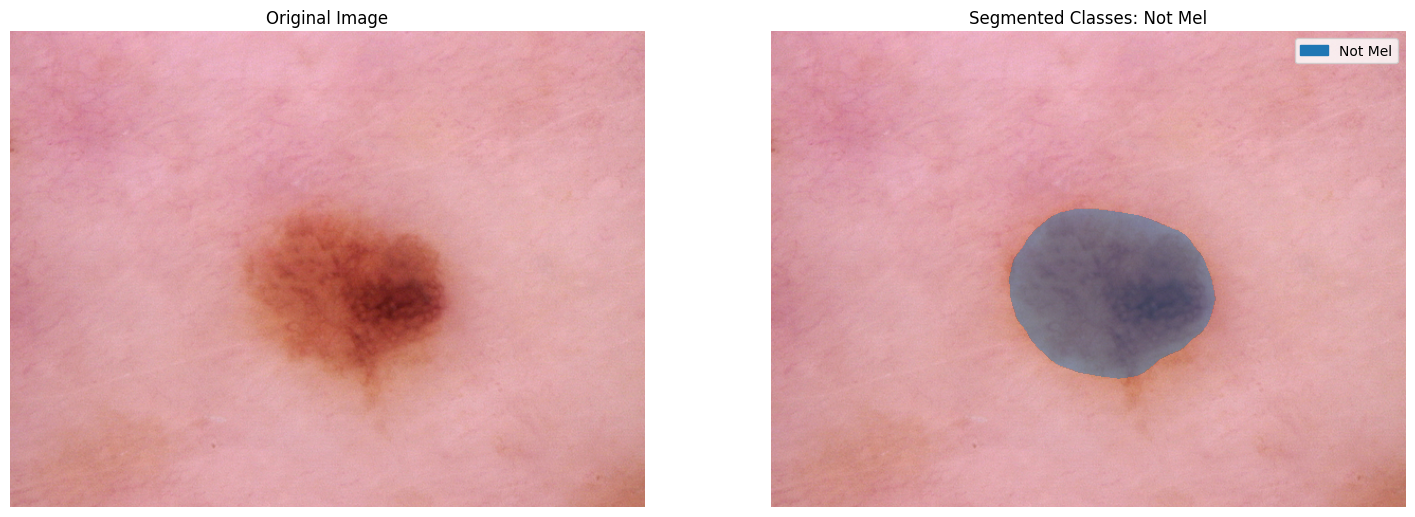

In [16]:
predict(mel_seg_model,s1_data_yaml['test'],save_dir=None,remove_background=False)

And again with the background removed, so only the segmented lesion remains in the output image.


0: 192x256 27.7ms
Speed: 4.1ms preprocess, 27.7ms inference, 56.5ms postprocess per image at shape (1, 3, 192, 256)
Classes present in this image: {1: 'Mel'}
Class: Mel (id=1) | BBox: (110, 49, 505, 413) | Pixels: 98221


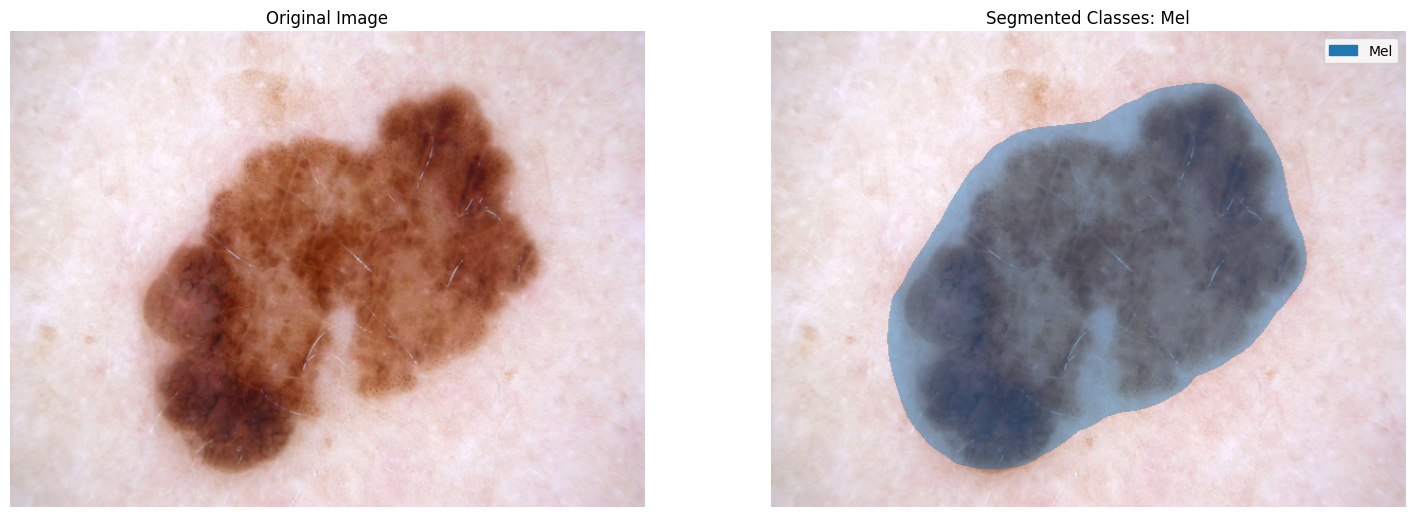

In [23]:
predict(mel_seg_model,s1_data_yaml['test'],save_dir=s1_save_dir,remove_background=True)

## Load the diagnosis segmentation model

Same pattern as stage 1. This model picks up training from the stage 1 checkpoint and segments the remaining diagnosis classes, with a different mask ratio. Training already happened, so the call stays commented out.


In [ ]:
# mel_seg_model.train(data=s2_data_yaml_path, 
#                  **s2_model_args, mask_ratio=2)

New https://pypi.org/project/ultralytics/8.4.140 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.139  Python-3.13.12 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 2060 SUPER, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=None, batch=128, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/processed/Stage-2/data.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.0, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.15, hsv_v=0.15, imgsz=256, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=2, max_det=300, 

ultralytics.utils.metrics.SemanticMetrics object with attributes:

ap_class_index: [0, 1, 2, 3, 4, 5, 6]
cm_nc: 7
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001D62F64DCC0>
curves: []
curves_results: []
fitness: 0.6128557324409485
keys: ['metrics/mIoU', 'metrics/pixel_acc']
matrix: tensor([[5.0139e+05, 3.0634e+04, 7.8914e+04, 0.0000e+00, 2.4812e+04, 0.0000e+00, 7.5276e+04],
        [9.7400e+03, 4.3006e+05, 1.4087e+05, 1.0238e+04, 1.0922e+05, 0.0000e+00, 1.6538e+05],
        [1.1658e+05, 1.1876e+04, 1.1745e+06, 4.1380e+03, 1.1665e+05, 1.6000e+01, 1.2987e+05],
        [3.0059e+04, 0.0000e+00, 5.0858e+04, 9.0082e+04, 6.2430e+03, 0.0000e+00, 1.5941e+04],
        [1.0785e+04, 1.3467e+04, 3.1822e+05, 0.0000e+00, 3.1111e+06, 0.0000e+00, 1.2748e+05],
        [0.0000e+00, 1.3770e+03, 0.0000e+00, 0.0000e+00, 1.7880e+03, 7.4099e+04, 9.1400e+03],
        [1.6063e+05, 9.4611e+04, 2.9270e+05, 5.1980e+03, 2.5141e+05, 7.5610e+03, 1.7756e+07]], device='cuda:0')
miou: 0.6

In [ ]:
# load the checkpoint saved at the end of training, this is the model we'll actually use for inference
diag_seg_model = YOLO(s2_weights['last'])

Let's run predictions with this model too, first without background removal.


0: 192x256 7.5ms
Speed: 0.9ms preprocess, 7.5ms inference, 0.7ms postprocess per image at shape (1, 3, 192, 256)
Classes present in this image: {2: 'BKL'}
Class: BKL (id=2) | BBox: (119, 67, 493, 430) | Pixels: 112519


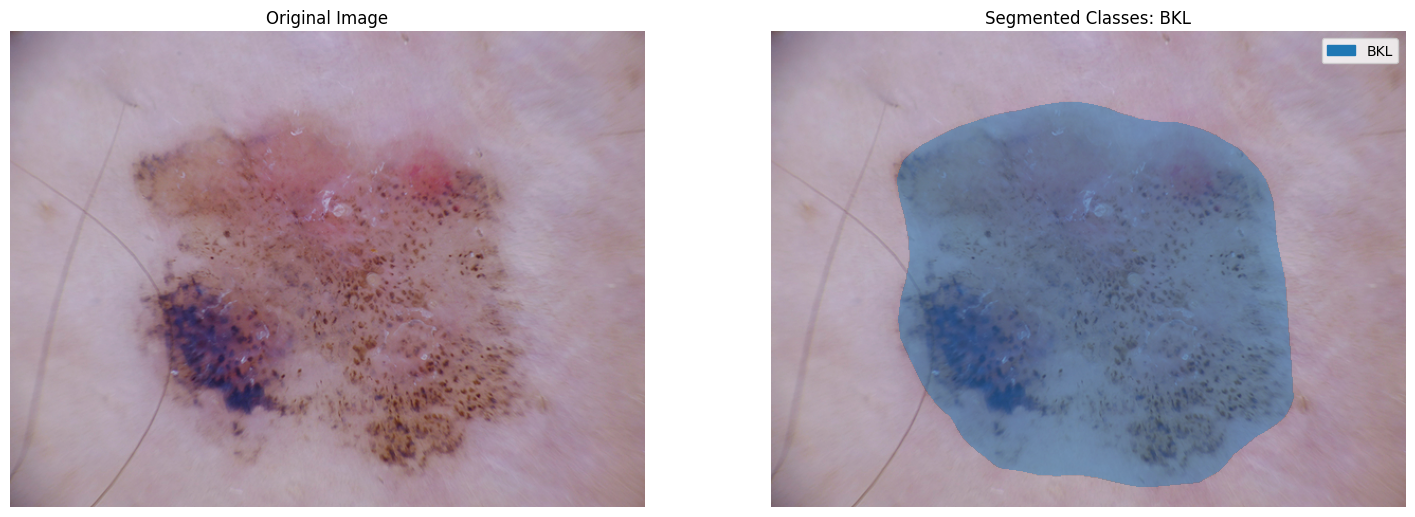

In [16]:
predict(diag_seg_model,s2_data_yaml['test'],save_dir=s2_save_dir,remove_background=False)

And then with the background removed.


0: 192x256 5.8ms
Speed: 3.8ms preprocess, 5.8ms inference, 0.7ms postprocess per image at shape (1, 3, 192, 256)
Classes present in this image: {5: 'VASC'}
Class: VASC (id=5) | BBox: (206, 179, 394, 327) | Pixels: 22848


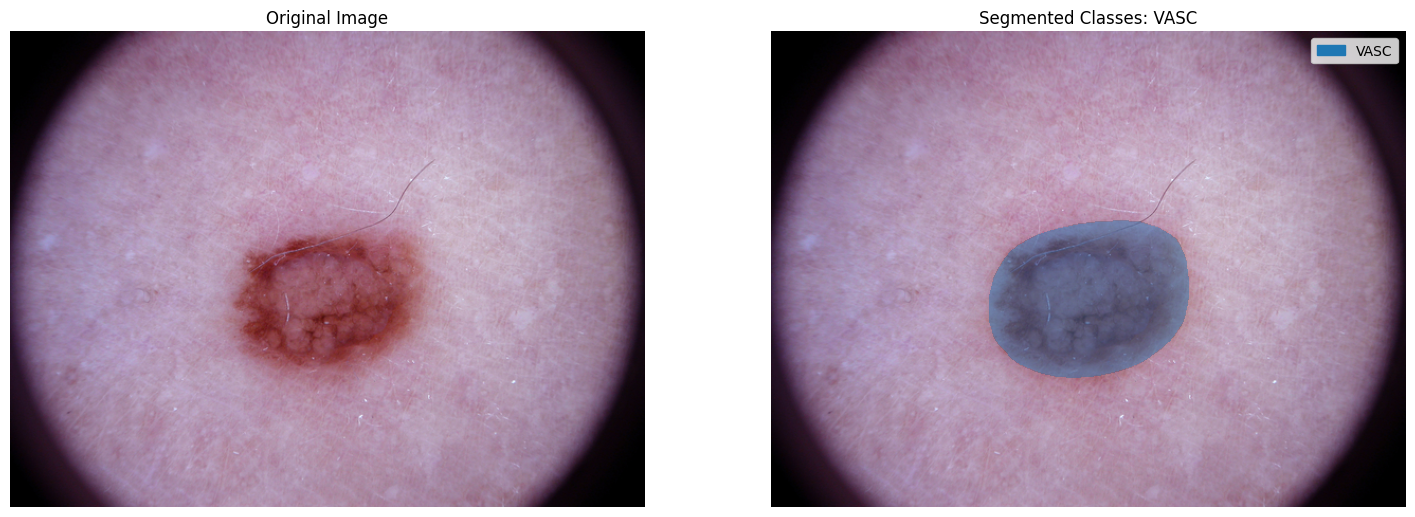

In [21]:
predict(diag_seg_model,s2_data_yaml['test'],save_dir=s2_save_dir,remove_background=True)